In [ ]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pandas as pd

Visualize time series of MJO index

C:\Users\wkkong\AppData\Local\Temp\ipykernel_16744\2771316305.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(


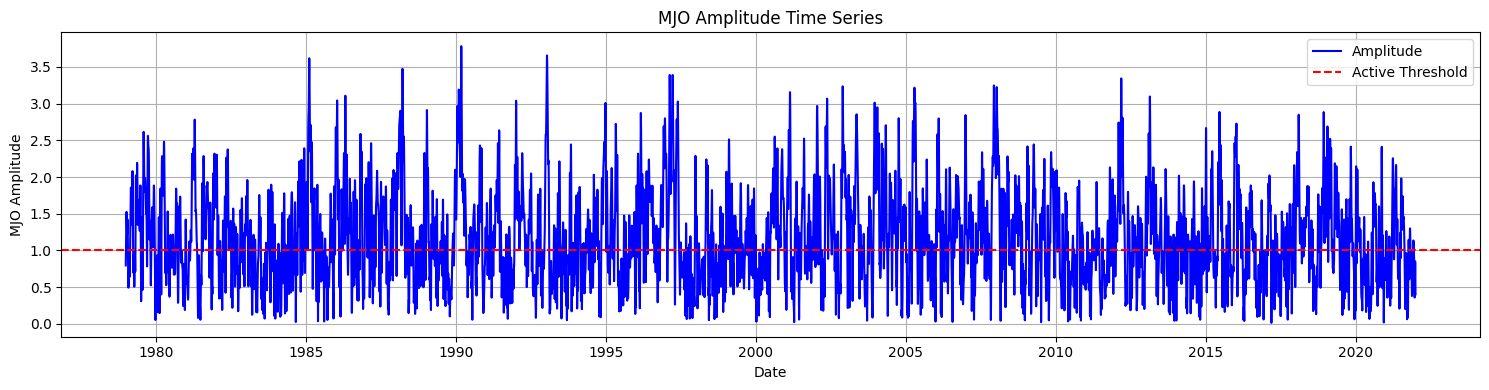

In [88]:
file_path = r"D:\KAUST\Hydro-climatic_EXtreme\meteSR\omi.1x.webpage.7921.txt"  #Change this to your actual file path

df = pd.read_csv(
    file_path,
    delim_whitespace=True,
    header=None,
    names=['Year','Month','Day','Hour','RMM1','RMM2','Amplitude']
)

df['Date'] = pd.to_datetime(df[['Year','Month','Day']])
plt.figure(figsize=(15,4))
plt.plot(df['Date'], df['Amplitude'], label='Amplitude', color='blue')
plt.axhline(1, color='red', linestyle='--', label='Active Threshold')  # 振幅>1活跃
plt.xlabel('Date')
plt.ylabel('MJO Amplitude')
plt.title('MJO Amplitude Time Series')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Prepare data for LSTM

In [89]:
# Time range
df_filtered = df[(df['Year'] >= 2000) & (df['Year'] <= 2020)]
data = df_filtered['Amplitude'].values.reshape(-1, 1)

# Train/Val/Test split
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

n_total = len(data)
n_train = int(n_total * train_ratio)
n_val = int(n_total * val_ratio)
n_test = n_total - n_train - n_val

train_data = data[:n_train]
val_data   = data[n_train:n_train+n_val]
test_data  = data[n_train+n_val:]

# normalize
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)

val_scaled  = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)


######################## create sequences for LSTM ########################
def create_dataset(data_scaled, seq_length=30, step_ahead=1):
    """
    data_scaled: series normalized to [0,1]
    seq_length: length of historical time steps
    step_ahead: predict the step_ahead-th time point in the future (1 means the next moment, 2 means the day after tomorrow, etc.)
    """
    X, y = [], []
    for i in range(len(data_scaled) - seq_length - step_ahead + 1):
        X.append(data_scaled[i:i+seq_length])
        y.append(data_scaled[i+seq_length + step_ahead - 1])
    return np.array(X), np.array(y)

seq_length = 30  # adjust based on MJO cycle
lead_times = [1, 3, 5, 7, 9]  # predict future 1~5 time steps
datasets = {}

for step in lead_times:
    X_tr, y_tr = create_dataset(train_scaled, seq_length, step_ahead=step)
    X_va, y_va = create_dataset(val_scaled, seq_length, step_ahead=step)
    X_te, y_te = create_dataset(test_scaled, seq_length, step_ahead=step)

    
    X_tr = X_tr.reshape((X_tr.shape[0], X_tr.shape[1], 1))
    X_va = X_va.reshape((X_va.shape[0], X_va.shape[1], 1))
    X_te = X_te.reshape((X_te.shape[0], X_te.shape[1], 1))

    
    X_tr = torch.from_numpy(X_tr).float()
    y_tr = torch.from_numpy(y_tr).float()
    X_va = torch.from_numpy(X_va).float()
    y_va = torch.from_numpy(y_va).float()
    X_te = torch.from_numpy(X_te).float()
    y_te = torch.from_numpy(y_te).float()

    
    datasets[step] = {
        "X_train": X_tr, "y_train": y_tr,
        "X_val": X_va, "y_val": y_va,
        "X_test": X_te, "y_test": y_te
    }

In [ ]:
#LSTM model
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])  
        return out

In [ ]:
num_epochs = 200
learning_rate = 0.01
models = {}

for step in lead_times:
    print(f"\nTraining model for lead time {step} ...")
    data = datasets[step]

    model = LSTMModel()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    X_tr, y_tr = data["X_train"], data["y_train"]
    X_va, y_va = data["X_val"], data["y_val"]

    for epoch in range(num_epochs):
        # Training
        model.train()
        outputs = model(X_tr)
        loss = criterion(outputs, y_tr)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_va)
            val_loss = criterion(val_outputs, y_va)

        if (epoch+1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

    models[step] = model


Training model for lead time 1 ...
Epoch [50/200], Train Loss: 0.0042, Val Loss: 0.0040
Epoch [100/200], Train Loss: 0.0007, Val Loss: 0.0008
Epoch [150/200], Train Loss: 0.0004, Val Loss: 0.0004
Epoch [200/200], Train Loss: 0.0005, Val Loss: 0.0004

Training model for lead time 3 ...
Epoch [50/200], Train Loss: 0.0108, Val Loss: 0.0106
Epoch [100/200], Train Loss: 0.0067, Val Loss: 0.0066
Epoch [150/200], Train Loss: 0.0034, Val Loss: 0.0035
Epoch [200/200], Train Loss: 0.0024, Val Loss: 0.0026

Training model for lead time 5 ...
Epoch [50/200], Train Loss: 0.0266, Val Loss: 0.0256
Epoch [100/200], Train Loss: 0.0200, Val Loss: 0.0185
Epoch [150/200], Train Loss: 0.0184, Val Loss: 0.0173
Epoch [200/200], Train Loss: 0.0152, Val Loss: 0.0146

Training model for lead time 7 ...
Epoch [50/200], Train Loss: 0.0258, Val Loss: 0.0230
Epoch [100/200], Train Loss: 0.0246, Val Loss: 0.0224
Epoch [150/200], Train Loss: 0.0206, Val Loss: 0.0174
Epoch [200/200], Train Loss: 0.0178, Val Loss: 0.0

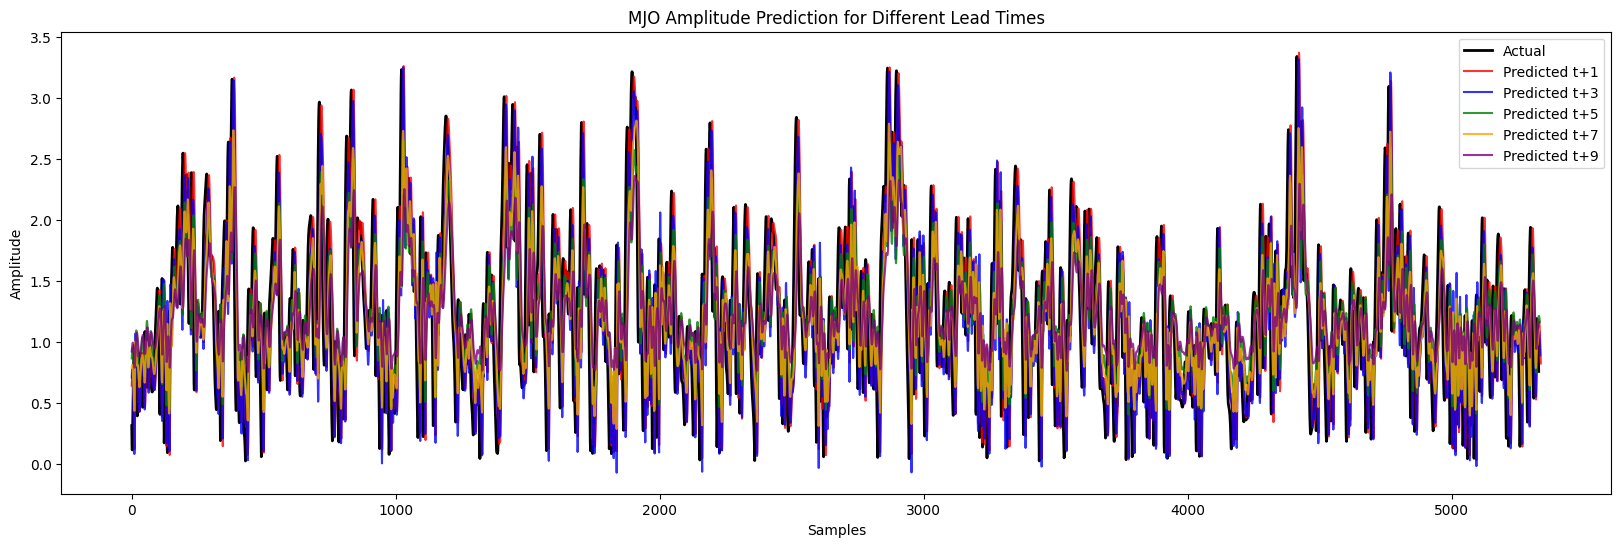

In [ ]:
# Visualize different lead time predictions

plt.figure(figsize=(20, 6))

# True values
actual = scaler.inverse_transform(y_tr.numpy())
plt.plot(actual, label='Actual', color='black', linewidth=2)

# Colors for different lead times
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, step in enumerate(lead_times):
    model = models[step]
    data = datasets[step]
    
    # Use training set for prediction
    model.eval()
    with torch.no_grad():
        predicted = model(data["X_train"]).detach().numpy()
    
    # Inverse transform to original scale
    predicted = scaler.inverse_transform(predicted)
    
    # Plot predicted values
    plt.plot(predicted, label=f'Predicted t+{step}', color=colors[i], alpha=0.8)

# Plot settings
plt.title("MJO Amplitude Prediction for Different Lead Times")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

Use symtorch to fit LSTM

In [137]:
from symtorch import SymbolicModel

In [101]:
dummy_models = {}  

for step in lead_times:  # lead_times = [1,2,3,4,5]
    model_step = models[step]
    data = datasets[step]
    
    
    model_step.eval()
    with torch.no_grad():
        y_pred = model_step(data["X_train"].view(-1, seq_length, 1)).squeeze(-1)  
    
    
    class DummyModel(nn.Module):
        def __init__(self, y):
            super().__init__()
            if y.dim() == 1:
                y = y.unsqueeze(1)  
            self.register_buffer("y", y)

        def forward(self, x):
            return self.y

    dummy_model = DummyModel(y_pred)
    
    
    dummy_models[step] = dummy_model


In [102]:
sr_models = {}  

for step in lead_times:  # lead_times = [1,2,3,4,5]
    print(f"\nDistilling lead time {step} ...")
    
    # DummyModel 
    dummy_model = dummy_models[step]
    data = datasets[step]
    X_tr = data["X_train"].reshape(data["X_train"].shape[0], -1)  
    
    # SymbolicModel
    model_sr = SymbolicModel(dummy_model, f"distilled_lstm_t{step}")
    
    # parameters for symbolic regression
    sr_params = {
        "niterations": 200,
        "complexity_of_constants": 1,
        "maxsize": 30,
        "binary_operators": ["+", "-", "*", "/"],
        "unary_operators": ["sin", "cos", "exp", "log"],
        "elementwise_loss": "loss(prediction, target) = abs(prediction - target)",
        "parsimony": 0.001,
        "batching": True,
        "random_state": 42,
    }

    fit_params = {
        "variable_names": [f"x{i}" for i in range(seq_length)]
    }
    
    # distill
    model_sr.distill(
        X_tr,
        sr_params=sr_params,
        fit_params=fit_params
    )
    
   
    sr_models[step] = model_sr


Distilling lead time 1 ...


d:\anaconda3\envs\torch_sym\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
d:\anaconda3\envs\torch_sym\Lib\site-packages\pysr\sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 8.000e+03
Progress: 765 / 6200 total iterations (12.339%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.110e-01  0.000e+00  y = x25
3           1.950e-02  8.696e-01  y = x29 * 0.98467
5           1.934e-02  4.008e-03  y = 0.0061372 - (x29 * -0.96982)
7           1.932e-02  6.205e-04  y = ((-0.10206 - x29) * -0.9739) - 0.092535
9           1.762e-02  4.590e-02  y = (x29 - -0.6703) - cos(cos(cos(cos(x25))))
10          1.584e-02  1.069e-01  y = (x29 - -0.8344) - cos(cos(cos(x25 + 2.5789)))
12          1.572e-02  3.831e-03  y = ((x29 - -0.81129) - cos(cos(cos(x25 + -0.59759)))) + 0...
                                      .022819
14          1.425e-02  4.892e-02  y = (x29 - -0.54996) - cos(sin((x25 + cos(x29)) + 0.41236)...
                      

[ Info: Final population:
[ Info: Results saved to:
d:\anaconda3\envs\torch_sym\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
d:\anaconda3\envs\torch_sym\Lib\site-packages\pysr\sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(



Distilling lead time 3 ...


...


Distilling lead time 9 ...
  - SR_output/distilled_lstm_t7\dim0_1773071098\hall_of_fame.csv

Expressions evaluated per second: 2.810e+03
Progress: 282 / 6200 total iterations (4.548%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.010e-02  0.000e+00  y = 0.34493
4           4.671e-02  1.353e-01  y = log(x28 - -1.1371)
5           1.162e-02  1.391e+00  y = (x28 * 0.42731) + 0.20222
8           8.216e-03  1.157e-01  y = exp((x28 * 1.2069) + -1.4803)
───────────────────────────────────────────────────────────────────────────────────────────────────
════════════════════════════════════════════════════════════════════════════════════════════════════
Press 'q' and then <enter> to stop execution early.


[ Info: Started!



Expressions evaluated per second: 2.860e+03
Progress: 572 / 6200 total iterations (9.226%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.010e-02  0.000e+00  y = 0.34493
4           4.671e-02  1.353e-01  y = log(x28 - -1.1371)
5           1.162e-02  1.391e+00  y = (x28 * 0.42731) + 0.20222
8           8.216e-03  1.157e-01  y = exp((x28 * 1.2069) + -1.4803)
9           5.121e-03  4.727e-01  y = (x29 * ((x24 + 1.1062) * 0.25329)) - -0.22107
28          4.609e-03  5.539e-03  y = ((x29 * ((sin((x13 * 0.69073) * (((x17 * x13) * (x13 *...
                                       x29)) * (x13 * x14))) + x24) + 1.2051)) * 0.2382) - -0.21...
                                      873
───────────────────────────────────────────────────────────────────────────────────────────────────
═══════

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           7.010e-02  0.000e+00  y = 0.34493
4           3.705e-02  2.126e-01  y = log(x28 + 1.0832)
5           1.150e-02  1.170e+00  y = (x28 * 0.4357) - -0.19996
7           1.051e-02  4.529e-02  y = ((x29 + x27) * 0.21967) - -0.19914
8           8.061e-03  2.649e-01  y = (exp(x28) + -0.26673) * 0.3011
9           5.055e-03  4.667e-01  y = (x29 * ((x24 + 1.0176) * 0.26541)) - -0.22217
13          4.102e-03  5.226e-02  y = ((x29 * ((x25 * x19) + (x25 + 1.8522))) * 0.15315) - -...
                                      0.22354
14          4.077e-03  6.009e-03  y = (((x24 + 1.1295) * ((cos(x15) * -0.076057) + 0.31482))...
                                       * x29) - -0.22277
15          3.530e-03  1.441e-01  y = ((x29 * (x25 + (1.5514 + ((x21 * x13) * x22)))) * 0.18...
                                      438) - -0.22303
17          2.850e-0

In [114]:
symbolic_functions = {}

for step in lead_times:  # lead_times = [1,2,3,4,5]
    model_sr = sr_models[step]
    sym_func = model_sr.get_symbolic_function(dim=0)
    
    symbolic_functions[step] = sym_func

In [115]:
X_flat = X_val.reshape(X_val.shape[0], -1)

In [116]:
y_symbolic_preds = {}

for step in lead_times:  # lead_times = [1,2,3,4,5]
    sym_func = symbolic_functions[step]
    X_val_step = datasets[step]["X_val"]  # shape: (num_samples, seq_length, 1)
    X_flat = X_val_step.reshape(X_val_step.shape[0], -1)  
    
    y_sym = sym_func(X_flat)
    
    y_symbolic_preds[step] = y_sym

In [117]:
with torch.no_grad():
    y_lstm = model(X_val).cpu().numpy()

In [118]:
y_true = y_val.cpu().numpy()

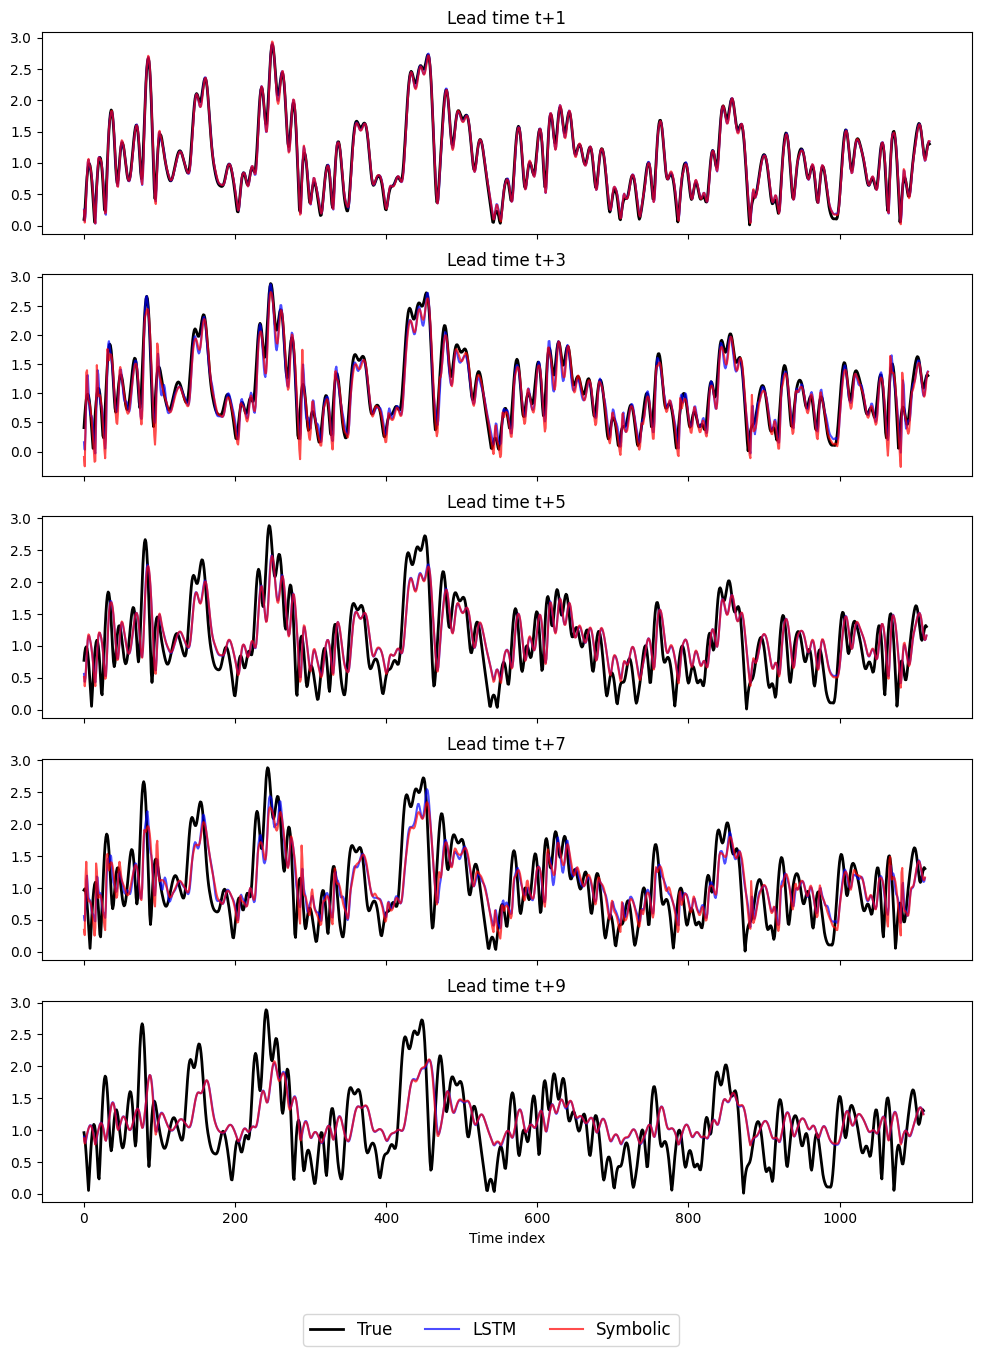

In [ ]:
lead_times = [1, 3, 5, 7, 9]
colors = ['red', 'blue', 'green', 'orange', 'purple']

fig, axes = plt.subplots(5, 1, figsize=(12, 15), sharex=True)

for i, step in enumerate(lead_times):
    ax = axes[i]
    
   
    y_true = scaler.inverse_transform(datasets[step]["y_val"].numpy())
    
    # LSTM 
    model = models[step]
    model.eval()
    with torch.no_grad():
        y_lstm = model(datasets[step]["X_val"]).detach().numpy()
    y_lstm = scaler.inverse_transform(y_lstm)
    
    # symbolic
    y_symbolic = y_symbolic_preds[step].reshape(-1, 1)
    y_symbolic = scaler.inverse_transform(y_symbolic)
    
    
    ax.plot(y_true, color='black', linewidth=2, label='True')
    ax.plot(y_lstm, color='blue', alpha=0.7, label='LSTM')
    ax.plot(y_symbolic, color='red', alpha=0.7, label='Symbolic')
    
    ax.set_title(f"Lead time t+{step}")


fig.subplots_adjust(bottom=0.1)  
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=12)

plt.xlabel("Time index")
plt.show()